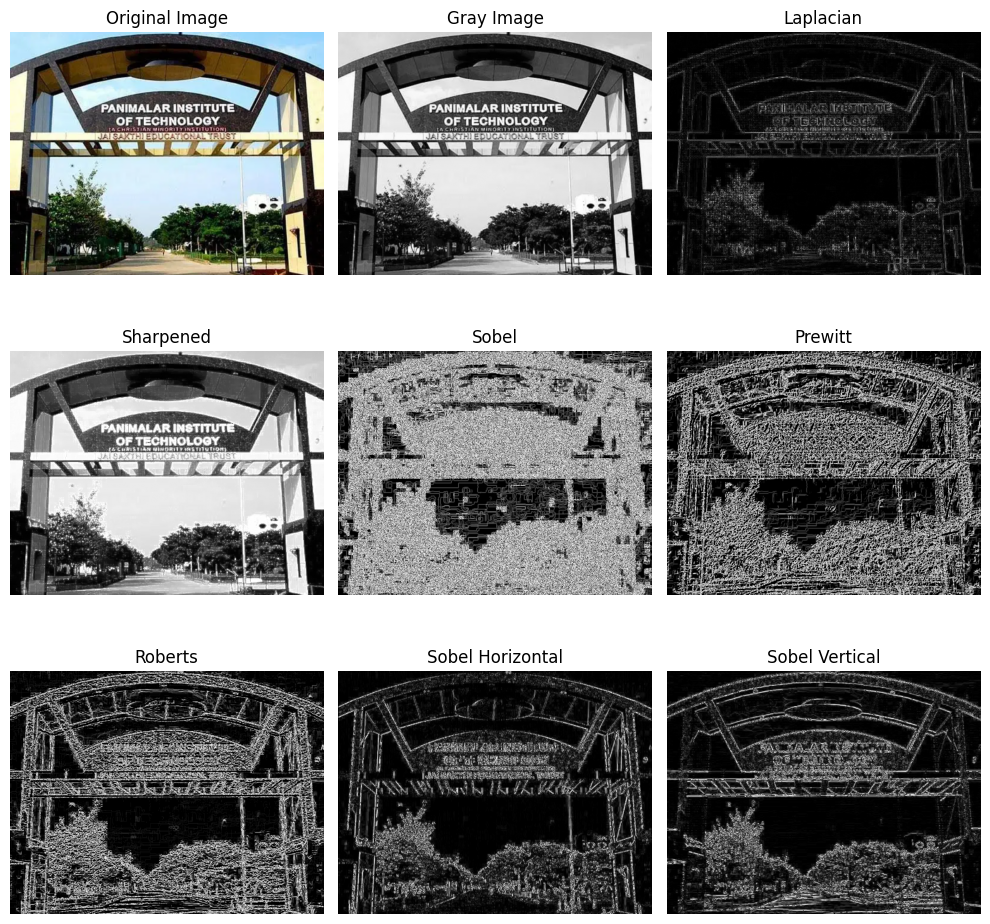

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("test6.png")  # change to your image path
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# -----------------------------
# 1. LAPLACIAN (Sharpening)
# -----------------------------
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# Sharpened image
sharpened = cv2.add(gray, laplacian)

# -----------------------------
# 2. SOBEL OPERATOR
# -----------------------------
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # Vertical

sobelx = np.uint8(np.absolute(sobelx))
sobely = np.uint8(np.absolute(sobely))

# Gradient magnitude
sobel = np.sqrt(sobelx**2 + sobely**2)
sobel = np.uint8(sobel)

# -----------------------------
# 3. PREWITT OPERATOR
# -----------------------------
kernelx = np.array([[1, 0, -1],
                    [1, 0, -1],
                    [1, 0, -1]])

kernely = np.array([[1, 1, 1],
                    [0, 0, 0],
                    [-1, -1, -1]])

prewittx = cv2.filter2D(gray, -1, kernelx)
prewitty = cv2.filter2D(gray, -1, kernely)

prewitt = np.sqrt(prewittx**2 + prewitty**2)
prewitt = np.uint8(prewitt)

# -----------------------------
# 4. ROBERTS OPERATOR
# -----------------------------
kernelx = np.array([[1, 0],
                    [0, -1]])

kernely = np.array([[0, 1],
                    [-1, 0]])

robertsx = cv2.filter2D(gray, -1, kernelx)
robertsy = cv2.filter2D(gray, -1, kernely)

roberts = np.sqrt(robertsx**2 + robertsy**2)
roberts = np.uint8(roberts)

# -----------------------------
# DISPLAY RESULTS
# -----------------------------
plt.figure(figsize=(10,10))

plt.subplot(3,3,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,3,2)
plt.title("Gray Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(3,3,3)
plt.title("Laplacian")
plt.imshow(laplacian, cmap='gray')
plt.axis('off')

plt.subplot(3,3,4)
plt.title("Sharpened")
plt.imshow(sharpened, cmap='gray')
plt.axis('off')

plt.subplot(3,3,5)
plt.title("Sobel")
plt.imshow(sobel, cmap='gray')
plt.axis('off')

plt.subplot(3,3,6)
plt.title("Prewitt")
plt.imshow(prewitt, cmap='gray')
plt.axis('off')

plt.subplot(3,3,7)
plt.title("Roberts")
plt.imshow(roberts, cmap='gray')
plt.axis('off')

plt.subplot(3,3,8)
plt.title("Sobel Horizontal")
plt.imshow(sobelx, cmap='gray')
plt.axis('off')

plt.subplot(3,3,9)
plt.title("Sobel Vertical")
plt.imshow(sobely, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()